In [35]:
import cv2
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import glob
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms #imports

device = 'cuda' if torch.cuda.is_available() else 'cpu' 

In [36]:
class Ben10Dataset(Dataset):
    def __init__(self, pasta):
        self.arquivos = glob.glob(pasta + '/*.*') #pega os dados
    def __len__(self):
        return len(self.arquivos)
    def __getitem__(self, idx): #pega a imagem
        img = cv2.imread(self.arquivos[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (128, 128)) #redimensiona
        lab_img = cv2.cvtColor(img, cv2.COLOR_RGB2LAB) #converte pra lab
        luz = lab_img[:, :, 0] #separa a luz
        cores = lab_img[:, :, 1:] #separa as cores
        tf = transforms.ToTensor() #passa pra tensor
        luz_tensor = tf(luz)
        cores_tensor = tf(cores)
        img_rgb_tensor = tf(img) #salva a original
        
        return luz_tensor, cores_tensor, img_rgb_tensor

treino = Ben10Dataset('dados/treino')
teste = Ben10Dataset('dados/teste') #imagens treino

treino_load = DataLoader(treino, batch_size=8, shuffle=True)
teste_load = DataLoader(teste, batch_size=4, shuffle=False) #dataloader e embaralha o treino

In [37]:
class Colorizador(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1), #camada convolucional
            nn.ReLU(), #ativacao
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), #aumenta a resolucao
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 2, kernel_size=4, stride=2, padding=1), 
            nn.Sigmoid() #ativacao
        )

    def forward(self, x): #fluxo do modelo
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [38]:
modelo = Colorizador().to(device) #modelo
opt = torch.optim.Adam(modelo.parameters(), lr=0.001) #otimizador
loss_func = nn.MSELoss() #funcao q pega o erro

In [39]:
for epoch in range(50):
    modelo.train()
    total_loss = 0
    for luz, cores, _ in treino_load:
        luz = luz.to(device)
        cores = cores.to(device)
        opt.zero_grad() #zera os gradiente pra ir pra nova epoch
        cores_previstas = modelo(luz)
        loss = loss_func(cores_previstas, cores)
        loss.backward() 
        opt.step() #att os pesos
        total_loss += loss.item()
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1} : Loss media: {total_loss/len(treino_load):.4f}")

Epoch 10 : Loss media: 0.0093
Epoch 20 : Loss media: 0.0089
Epoch 30 : Loss media: 0.0084
Epoch 40 : Loss media: 0.0082
Epoch 50 : Loss media: 0.0074


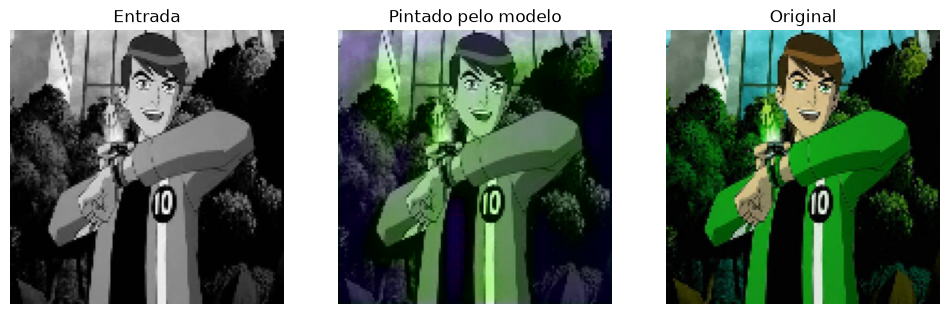

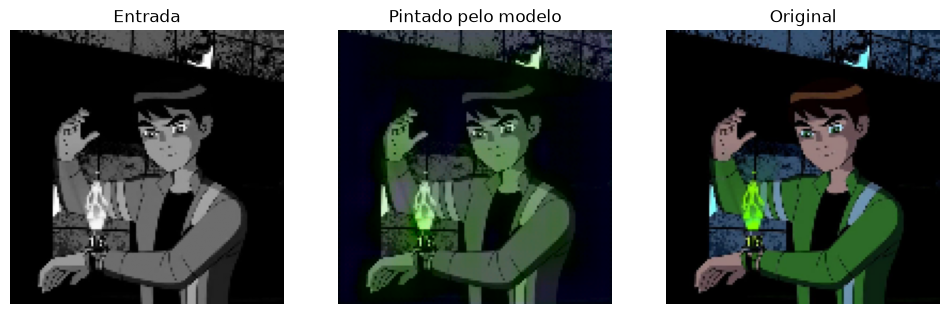

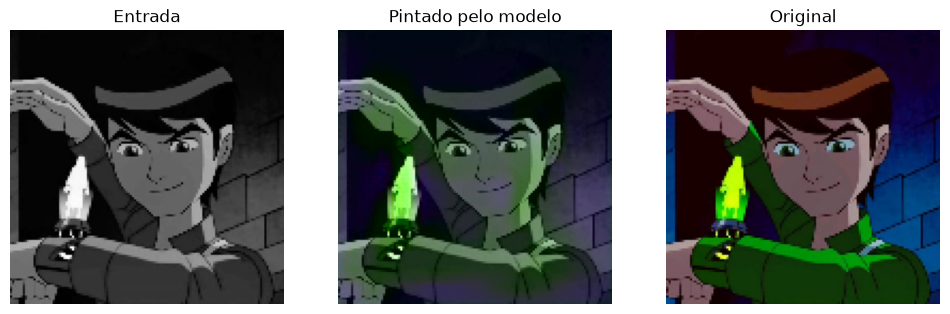

In [40]:
modelo.eval() 
luz_teste, cores_reais, img_rgb_real = next(iter(teste_load))
with torch.no_grad(): 
    cores_previstas = modelo(luz_teste.to(device)).cpu()  #teste
for i in range(len(luz_teste)):
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    
    ax[0].imshow(luz_teste[i].squeeze(), cmap='gray')
    ax[0].set_title("Entrada")
    ax[0].axis('off')
    
    l_np = luz_teste[i].permute(1, 2, 0).numpy()
    ab_np = cores_previstas[i].permute(1, 2, 0).numpy()
    lab_fake = np.concatenate((l_np, ab_np), axis=2) #junta luz com cor
    lab_fake_uint8 = (lab_fake * 255).astype(np.uint8) #volta formato
    rgb_fake = cv2.cvtColor(lab_fake_uint8, cv2.COLOR_LAB2RGB) #transforma pra rgb
    
    ax[1].imshow(rgb_fake)
    ax[1].set_title("Pintado pelo modelo")
    ax[1].axis('off')
    
    ax[2].imshow(img_rgb_real[i].permute(1, 2, 0).numpy())
    ax[2].set_title("Original")
    ax[2].axis('off') #mostra a original oq o modelo preve e oq entrou
    
    plt.show()